In [6]:
#importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS


In [7]:
data = pd.read_excel("covid_19_clean_complete.csv")
data.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  str           
 1   Country/Region  49068 non-null  str           
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[us]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(4), str(3)
memory usage: 3.7 MB


In [9]:
data.describe

<bound method NDFrame.describe of       Province/State         Country/Region        Lat       Long       Date  \
0                NaN            Afghanistan  33.939110  67.709953 2020-01-22   
1                NaN                Albania  41.153300  20.168300 2020-01-22   
2                NaN                Algeria  28.033900   1.659600 2020-01-22   
3                NaN                Andorra  42.506300   1.521800 2020-01-22   
4                NaN                 Angola -11.202700  17.873900 2020-01-22   
...              ...                    ...        ...        ...        ...   
49063            NaN  Sao Tome and Principe   0.186400   6.613100 2020-07-27   
49064            NaN                  Yemen  15.552727  48.516388 2020-07-27   
49065            NaN                Comoros -11.645500  43.333300 2020-07-27   
49066            NaN             Tajikistan  38.861000  71.276100 2020-07-27   
49067            NaN                Lesotho -29.610000  28.233600 2020-07-27   

     

In [11]:
data.select_dtypes(include=['int64','float64'])

,Lat,Long,Confirmed,Deaths,Recovered,Active
0,33.939110,67.709953,0,0,0,0
1,41.153300,20.168300,0,0,0,0
2,28.033900,1.659600,0,0,0,0
3,42.506300,1.521800,0,0,0,0
4,-11.202700,17.873900,0,0,0,0
...,...,...,...,...,...,...
49063,0.186400,6.613100,865,14,734,117
49064,15.552727,48.516388,1691,483,833,375
49065,-11.645500,43.333300,354,7,328,19
49066,38.861000,71.276100,7235,60,6028,1147


In [12]:
data.select_dtypes(include=['object'])

C:\Users\hiten\AppData\Local\Temp\ipykernel_6780\3251308434.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include=['object'])


,Province/State,Country/Region,WHO Region
0,NaN,Afghanistan,Eastern Mediterranean
1,NaN,Albania,Europe
2,NaN,Algeria,Africa
3,NaN,Andorra,Europe
4,NaN,Angola,Africa
...,...,...,...
49063,NaN,Sao Tome and Principe,Africa
49064,NaN,Yemen,Eastern Mediterranean
49065,NaN,Comoros,Africa
49066,NaN,Tajikistan,Europe


In [13]:
top_countries = data.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)
top_countries.head()

Country/Region
US        224345948
Brazil     89524967
Russia     45408411
India      40883464
Spain      27404045
Name: Confirmed, dtype: int64

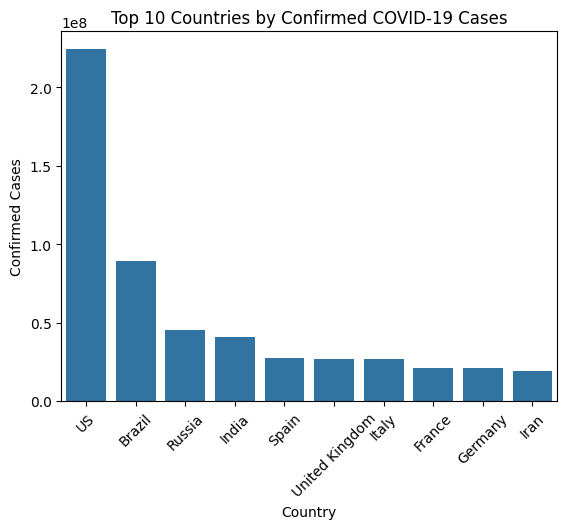

In [14]:
sns.barplot(x=top_countries.index, y=top_countries.values)
plt.title("Top 10 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.show()

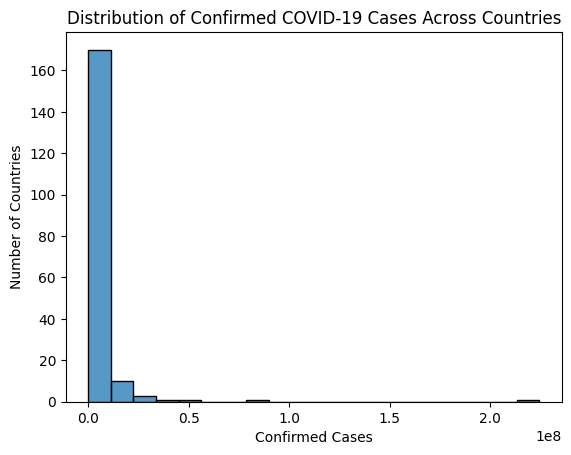

In [16]:
country_cases = data.groupby('Country/Region')['Confirmed'].sum()

sns.histplot(country_cases, bins=20)
plt.title("Distribution of Confirmed COVID-19 Cases Across Countries")
plt.xlabel("Confirmed Cases")
plt.ylabel("Number of Countries")
plt.show()

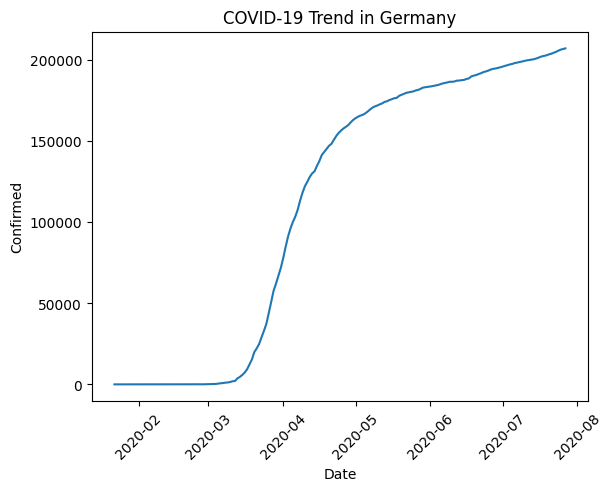

In [19]:
import seaborn as sns

country_data = data[data['Country/Region'] == 'Germany']

country_data['Date'] = pd.to_datetime(country_data['Date'])

sns.lineplot(x='Date', y='Confirmed', data=country_data)

plt.title("COVID-19 Trend in Germany")
plt.xticks(rotation=45)
plt.show()

In [20]:
text = " ".join(data['Country/Region'].astype(str))

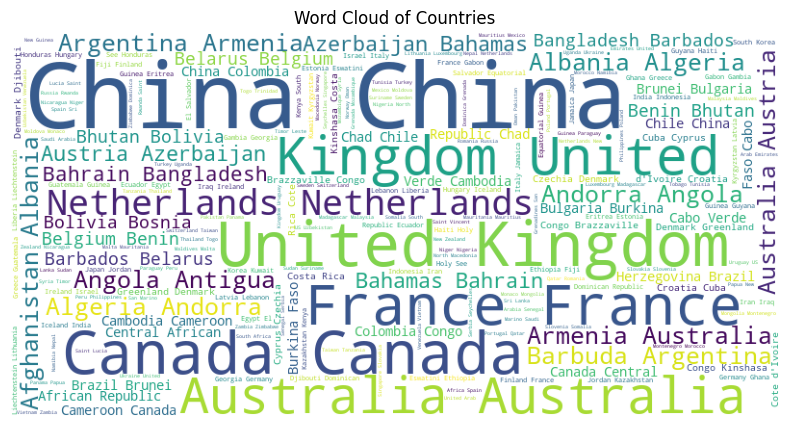

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Countries")
plt.show()

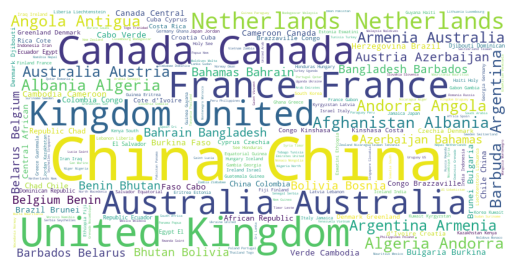

In [22]:
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      stopwords=stopwords).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.show()